In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


df = pd.read_parquet('../data/heart_disease_preprocessed.parquet')
columnas_num = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
columnas_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

def obtener_metricas_test(y_test, y_pred, y_proba):
    return {
        "Exactitud": accuracy_score(y_test, y_pred),
        "Precisión": precision_score(y_test, y_pred),
        "Sensibilidad": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

# Introducción

Tras la caracterización estadística del dataset, esta fase se centra en la construcción de un ecosistema de modelado bajo estándares de alta fidelidad científica, donde el desafío técnico principal es la mitigación de la fuga de datos (Data Leakage). En el ámbito clínico, este fenómeno ocurre cuando el conocimiento del conjunto de prueba contamina el entrenamiento a través de los parámetros de escalado o las correlaciones de la imputación MICE, lo que genera métricas artificialmente optimistas que colapsarían en un entorno hospitalario real. Para blindar este flujo, se implementó una arquitectura basada en Pipelines y GridSearchCV, la cual asegura que tanto las transformaciones como la optimización de hiperparámetros se ejecuten estrictamente sobre los pliegues de entrenamiento mediante validación cruzada. Este diseño modular facilita un benchmarking multimodelo que incluye Regresión Logística, Random Forest, KNN y Gradient Boosting, permitiendo generar un ranking comparativo que prioriza la estabilidad y la capacidad de generalización frente a la complejidad de los datos médicos.

# Entrenamiento con fuga

Para ilustrar el impacto de este fenómeno en la validez de los resultados, se presenta a continuación un experimento comparativo utilizando un modelo de máquinas de soporte vectorial (SVC). Este ejercicio se centra en dos de las fuentes de error más frecuentes en la práctica: la inclusión de variables con fuga, que incorporan información del objetivo que no estaría disponible en un diagnóstico real, y el mal uso del escalado al realizarlo sobre el conjunto de datos completo antes de la división de entrenamiento y prueba. A través de este contraste, es posible evidenciar cómo estas fallas metodológicas inflan artificialmente el desempeño del modelo y comprometen su utilidad clínica.

In [119]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import IterativeImputer
from IPython.display import display, HTML

# 1. Preparación de datos y definición de columnas
columnas_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# --- ESCENARIO 1: MODELO CON FUGA (LEAKAGE) ---
# A. Introducción de variable con fuga (leaky feature)
np.random.seed(0)
X_leak = X.copy()
X_leak["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))

# B. Split y Preprocesamiento Base (Encoding y MICE realizados correctamente)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_leak, y, test_size=0.2, random_state=42)

pre_base_l = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_cat)], remainder='passthrough')
imputador_l = IterativeImputer(random_state=42)

# Fit solo en train, transform en ambos (MICE y Encoding están bien hechos)
X_tr_prep_l = imputador_l.fit_transform(pre_base_l.fit_transform(X_train_l))
X_te_prep_l = imputador_l.transform(pre_base_l.transform(X_test_l))

# C. EL ERROR DEL PROFESOR: Escalado Global (Fuga de información)
scaler_leak = RobustScaler().fit(np.vstack((X_tr_prep_l, X_te_prep_l)))
X_tr_final_l = scaler_leak.transform(X_tr_prep_l)
X_te_final_l = scaler_leak.transform(X_te_prep_l)

grid_leak = GridSearchCV(
    SVC(probability=True), 
    param_grid={"C": [0.1, 1, 10], "gamma": [0.01, 0.1]}, 
    cv=5, 
    scoring="roc_auc", 
    n_jobs=-1
)
grid_leak.fit(X_tr_final_l, y_train_l)

# --- ESCENARIO 2: MODELO SIN FUGA (ÍNTEGRO) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline que asegura integridad total en cada fold (MICE, Encoding y Scaling)
pipe_clean = Pipeline([
    ('encoding', ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_cat)], remainder='passthrough')),
    ('imputador', IterativeImputer(random_state=42)),
    ('scaler', RobustScaler()),
    ('svc', SVC(probability=True))
])

grid_clean = GridSearchCV(
    pipe_clean, 
    param_grid={"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}, 
    cv=10, 
    scoring="roc_auc", 
    n_jobs=-1
)
grid_clean.fit(X_train, y_train)

def comparar_resultados_test(mod_l, xt_l, yt_l, mod_c, xt_c, yt_c):
    # Predicciones y probabilidades
    y_pred_l, y_prob_l = mod_l.predict(xt_l), mod_l.predict_proba(xt_l)[:, 1]
    y_pred_c, y_prob_c = mod_c.predict(xt_c), mod_c.predict_proba(xt_c)[:, 1]

    metricas = [
        ("Exactitud", accuracy_score),
        ("Precisión", precision_score),
        ("Sensibilidad", recall_score),
        ("F1-Score", f1_score),
        ("ROC-AUC", roc_auc_score)
    ]

    res_data = []
    for nombre, func in metricas:
        val_l = func(yt_l, y_prob_l) if nombre == "ROC-AUC" else func(yt_l, y_pred_l)
        val_c = func(yt_c, y_prob_c) if nombre == "ROC-AUC" else func(yt_c, y_pred_c)
        res_data.append([nombre, f"{val_l:.3f}", f"{val_c:.3f}", f"{val_l - val_c:.3f}"])

    df_final = pd.DataFrame(res_data, columns=["Métrica", "Modelo con Fuga", "Modelo sin Fuga", "Diferencia"])
    
    # Aplicar estilización exacta solicitada
    styled_table = df_final.style.hide(axis='index').set_table_styles([
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto')]},
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), 
                                     ('border', '1px solid black'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid black'), ('padding', '10px'), ('text-align', 'center')]}
    ])
    
    # Renderizado en div centrado
    display(HTML("<div style='text-align: center; width: 100%; margin-top: 10px;'>" + 
                 styled_table.to_html() + "</div>"))

comparar_resultados_test(grid_leak, X_te_final_l, y_test_l, grid_clean.best_estimator_, X_test, y_test)

Métrica,Modelo con Fuga,Modelo sin Fuga,Diferencia
Exactitud,1.000,0.864,0.136
Precisión,1.000,0.902,0.098
Sensibilidad,1.000,0.860,0.140
F1-Score,1.000,0.880,0.120
ROC-AUC,1.000,0.928,0.072


Tal como se observa en la tabla de resultados, el modelo con fuga de datos consiguió presuntamente métricas perfectas en el conjunto de prueba al alcanzar un valor de 1.000 en todos los indicadores. Este rendimiento es una consecuencia técnica de la contaminación del proceso de entrenamiento por la inclusión de la variable artificial y el ajuste global del escalador. Al no aislar el conjunto de prueba durante estas transformaciones, el clasificador accede a información que invalida la estimación del error de generalización. En contraste, el modelo sin fuga refleja el desempeño real del sistema sobre datos no observados, demostrando que la diferencia en las métricas representa el optimismo estadístico generado por la ruptura de la integridad del flujo de datos. El uso de Pipelines permite mitigar este sesgo al garantizar que cada etapa del preprocesamiento se ejecute exclusivamente bajo los parámetros aprendidos en el conjunto de entrenamiento.

In [122]:
from sklearn.model_selection import StratifiedKFold

def entrenar_modelo(X_train, y_train, estimador, malla_parametros, nombre_paso="clf", scoring='roc_auc'):
    """
    Entrena el modelo usando validación cruzada estratificada y 
    devuelve un ranking visual de las mejores 5 configuraciones.
    """
    # 1. Configuración de Grupos y Pipeline (Se mantiene igual)
    columnas_num = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
    columnas_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
    
    pipeline_final = Pipeline([
        ('encoding', ColumnTransformer([
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_cat)
        ], remainder='passthrough')),
        ('imputador_mice', IterativeImputer(random_state=42)),
        ('escalador', ColumnTransformer([
            ('robusto', RobustScaler(), list(range(-len(columnas_num), 0)))
        ], remainder='passthrough')),
        (nombre_paso, estimador)
    ])

    # 2. Definición Explícita de la Partición Estratificada
    # shuffle=True asegura que los datos se mezclen antes de dividir, 
    # y random_state garantiza que el experimento sea reproducible.
    cv_estratificado = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # 3. GridSearchCV con CV Estratificado
    busqueda_grid = GridSearchCV(
        estimator=pipeline_final,
        param_grid=malla_parametros,
        cv=cv_estratificado,  # <--- Aplicamos la partición explícita aquí
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False 
    )

    busqueda_grid.fit(X_train, y_train)

    # 4. Procesamiento y Renderizado (Se mantiene igual que tu versión anterior)
    resultados = pd.DataFrame(busqueda_grid.cv_results_)
    params_df = pd.json_normalize(resultados['params'])
    params_df.columns = [col.split('__')[-1] for col in params_df.columns]
    nombre_metrica = scoring.upper().replace('_', '-')
    
    resultados[nombre_metrica] = resultados.apply(
        lambda x: f"{x['mean_test_score']:.3f} ± {x['std_test_score']:.3f}", axis=1
    )
    
    df_ranking = pd.concat([params_df, resultados[[nombre_metrica, 'rank_test_score']]], axis=1)
    df_top_5 = df_ranking.sort_values(by='rank_test_score').head(5).drop(columns=['rank_test_score'])
    
    styled_table = df_top_5.style.hide(axis='index').set_table_styles([
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto')]},
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), 
                                     ('border', '1px solid black'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid black'), ('padding', '10px'), ('text-align', 'center')]}
    ])

    display(HTML("<div style='text-align: center; width: 100%; margin-top: 10px;'>" + 
                 styled_table.to_html() + "</div>"))
    
    return busqueda_grid

In [154]:
def evaluar_modelo(estimador, parametros, X_train, y_train, X_test, y_test, umbral_alerta=0.03):
    """
    Entrena el Pipeline final una sola vez con parámetros ideales y evalúa en Test.
    Devuelve el modelo entrenado y muestra el reporte de métricas.
    """
    # 1. Grupos de variables
    columnas_num = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
    columnas_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
    
    # 2. Construcción del Pipeline de Producción (Aislamiento Total)
    pipeline_final = Pipeline([
        ('encoding', ColumnTransformer([
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_cat)
        ], remainder='passthrough')),
        
        ('imputador_mice', IterativeImputer(random_state=42)),
        
        ('escalador', ColumnTransformer([
            ('robusto', RobustScaler(), list(range(-len(columnas_num), 0)))
        ], remainder='passthrough')),
        
        ('modelo', estimador)
    ])

    # 3. Seteo de hiperparámetros (Limpieza dinámica de prefijos)
    # Esto permite pasar 'svc__C' o 'logit__C' y que se asigne correctamente a 'modelo__C'
    params_ajustados = {f'modelo__{k.split("__")[-1]}': v for k, v in parametros.items()}
    pipeline_final.set_params(**params_ajustados)
    
    # 4. Entrenamiento único (Fit solo en Train)
    pipeline_final.fit(X_train, y_train)

    # 5. Predicciones para diagnóstico de Gap
    y_tr_pred = pipeline_final.predict(X_train)
    y_tr_prob = pipeline_final.predict_proba(X_train)[:, 1]
    
    y_te_pred = pipeline_final.predict(X_test)
    y_te_prob = pipeline_final.predict_proba(X_test)[:, 1]

    # 6. Cálculo de Métricas
    metrics = {
        'Métrica': ['Exactitud', 'Precisión', 'Sensibilidad', 'F1-Score', 'ROC-AUC'],
        'Entrenamiento': [
            accuracy_score(y_train, y_tr_pred), precision_score(y_train, y_tr_pred),
            recall_score(y_train, y_tr_pred), f1_score(y_train, y_tr_pred),
            roc_auc_score(y_train, y_tr_prob)
        ],
        'Prueba': [
            accuracy_score(y_test, y_te_pred), precision_score(y_test, y_te_pred),
            recall_score(y_test, y_te_pred), f1_score(y_test, y_te_pred),
            roc_auc_score(y_test, y_te_prob)
        ]
    }
    
    df_resumen = pd.DataFrame(metrics)
    df_resumen['Diferencia'] = (df_resumen['Entrenamiento'] - df_resumen['Prueba']).abs()

    # 7. Formateo y Estilo de la Tabla
    def format_gap(val):
        return f"{val:.3f}†" if val > umbral_alerta else f"{val:.3f}"

    styled_table = df_resumen.style.hide(axis='index').format({
        'Entrenamiento': '{:.3f}',
        'Prueba': '{:.3f}',
        'Diferencia': format_gap
    }).set_table_styles([
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto')]},
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), 
                                     ('border', '1px solid black'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid black'), ('padding', '10px'), ('text-align', 'center')]}
    ])

    # Renderizado
    display(HTML("<div style='text-align: center; width: 100%; margin-top: 10px;'>" + 
                 styled_table.to_html() + "</div>"))
    
    return pipeline_final # Retornamos el objeto listo para inferencia

In [59]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento sin fuga

Con el fin de estandarizar la experimentación, se ha consolidado el método `entrenar_modelo`, el cual integra la codificación, la imputación y el escalado en un Pipeline de entrenamiento seguro. Este flujo garantiza que todas las transformaciones de datos se ejecuten de forma estanca durante la validación cruzada, evitando sesgos por fuga de información en cada iteración. En las secciones siguientes se entrenarán múltiples modelos de clasificación con el propósito de comparar su rendimiento frente al SVC bajo estas condiciones de integridad metodológica.

Para la optimización de los hiperparámetros se ha seleccionado el área bajo la curva (AUC-ROC) como métrica principal, dado que permite evaluar la capacidad de discriminación del modelo de forma global, independientemente del umbral de clasificación seleccionado. A pesar de que el dataset no presenta desbalances marcados en la variable de respuesta, se utiliza un esquema de Stratified K-Fold de 10 pliegues. Esta elección asegura que la proporción de las clases se mantenga constante en cada partición de entrenamiento y validación, aportando mayor robustez estadística al proceso y facilitando una comparación equitativa entre los diversos algoritmos.

## Clasificador Dummy

Para establecer un punto de comparación básico, iniciaremos con el **Dummy Classifier**. Este modelo sirve como un benchmark o línea base, ya que realiza predicciones utilizando reglas heurísticas simples (como predecir siempre la clase mayoritaria o hacerlo de forma aleatoria) sin aprender realmente de las características de los datos. Si un modelo complejo no es capaz de superar significativamente el desempeño de este clasificador, es un indicio de que los datos no contienen patrones útiles o que el modelo está mal configurado.

En este caso, evaluaremos diversas estrategias para el **Dummy Classifier** con el fin de obtener la métrica de AUC-ROC base que cualquier clasificador posterior deberá superar con creces.

In [123]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(random_state=42)
parametros_dummy = {
    'dummy__strategy': ['most_frequent', 'stratified', 'prior']
}
resultado_dummy = entrenar_modelo(
    X_train, 
    y_train, 
    dummy_model, 
    parametros_dummy, 
    nombre_paso="dummy"
)

strategy,ROC-AUC
stratified,0.503 ± 0.054
most_frequent,0.500 ± 0.000
prior,0.500 ± 0.000


Los resultados de la validación cruzada indican que el **Dummy Classifier** establece una línea base de 0.500 en el AUC-ROC, lo cual representa la ausencia total de capacidad discriminativa o el equivalente estadístico al azar. Las estrategias de most_frequent y prior obtienen este valor de forma constante debido a que no emplean las variables predictoras para jerarquizar los casos, mientras que la estrategia stratified introduce una ligera variabilidad propia de la predicción aleatoria basada en la distribución de clases. Con el fin de evaluar la capacidad de generalización del modelo, a continuación se presentan los resultados obtenidos en la muestra de prueba.

In [155]:
parametros_dummy_ideales = {'strategy': 'most_frequent'}
pipeline_dummy = evaluar_modelo(
    estimador=DummyClassifier(),
    parametros=parametros_dummy_ideales,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Métrica,Entrenamiento,Prueba,Diferencia
Exactitud,0.546,0.582,0.035†
Precisión,0.546,0.582,0.035†
Sensibilidad,1.000,1.000,0.000
F1-Score,0.707,0.735,0.029
ROC-AUC,0.500,0.500,0.000


Los resultados del **Dummy Classifier** establecen el suelo estadístico del experimento con un AUC-ROC de 0.500, lo que confirma una capacidad predictiva nula equivalente al azar. La sensibilidad de 1.000 frente a la precisión de 0.582 en la muestra de prueba indica una estrategia de predicción constante de la clase mayoritaria, validando la arquitectura del flujo antes de introducir modelos con capacidad de aprendizaje. Es importante señalar que las dagas ($\dagger$) en exactitud y precisión, que marcan una diferencia de 0.035, responden a la variabilidad inherente en la distribución de las clases entre las particiones y no a un proceso de sobreajuste. Este benchmark garantiza que cualquier ganancia obtenida en las etapas posteriores sea atribuible a la captura de patrones clínicos genuinos y no a sesgos de frecuencia en los datos.

## Modelo Logístico

Tras definir el umbral base con el **Dummy Classifier**, se implementa el **Modelo Logístico** como el primer algoritmo con capacidad de aprendizaje del experimento. Este algoritmo utiliza la función sigmoide para transformar la combinación lineal de las variables en una probabilidad acotada entre 0 y 1, facilitando la clasificación binaria de los registros. Su selección responde a su alta interpretabilidad, permitiendo cuantificar el impacto de los predictores clínicos mediante sus coeficientes. El entrenamiento se realiza bajo el flujo de Pipelines consolidado, centrando la hiperparametrización en el factor de regularización para equilibrar la complejidad del modelo y su capacidad de generalización.

In [126]:
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
parametros_logit = {
    'logit__C': [0.01, 0.05, 0.1, 0.5,0.8, 1, 5, 10],
    'logit__penalty': ['l1', 'l2']
}

resultado_logit = entrenar_modelo(
    X_train, 
    y_train, 
    logit_model, 
    parametros_logit, 
    nombre_paso="logit"
)

C,penalty,ROC-AUC
0.100000,l2,0.925 ± 0.015
0.050000,l2,0.924 ± 0.015
0.500000,l1,0.923 ± 0.016
0.100000,l1,0.923 ± 0.019
0.500000,l2,0.923 ± 0.015


Los resultados de la hiperparametrización para el **Modelo Logístico** indican que la mejor configuración se obtiene con un parámetro de regularización $C = 0.1$ y penalización $l2$, alcanzando un ROC-AUC promedio de $0.925 \pm 0.015$. La reducida desviación estándar observada en las cinco mejores combinaciones confirma la estabilidad del modelo a través de los diferentes pliegues de la validación cruzada estratificada. Asimismo, la proximidad entre los valores de desempeño sugiere que el algoritmo es robusto ante variaciones menores en este rango de hiperparámetros. Al contrastar este resultado con el 0.500 del benchmark aleatorio, se ratifica una mejora sustancial en la capacidad de discriminación clínica, manteniendo niveles de rendimiento realistas frente al sesgo observado en el escenario con fuga de datos. Con el fin de evaluar la capacidad de generalización final, a continuación se presentan las métricas obtenidas en la muestra de prueba.

In [156]:
parametros_logit = {'logit__C': 0.1, 'logit__penalty': 'l2'}

pipeline_logit = evaluar_modelo(
    estimador=logit_model,
    parametros=parametros_logit,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Métrica,Entrenamiento,Prueba,Diferencia
Exactitud,0.862,0.859,0.004
Precisión,0.861,0.909,0.049†
Sensibilidad,0.893,0.841,0.052†
F1-Score,0.876,0.874,0.003
ROC-AUC,0.929,0.923,0.006


Tal como se observa en los resultados finales de la muestra de prueba, la Regresión Logística alcanza un ROC-AUC de $0.923$, manteniendo un desempeño consistente respecto a la fase de entrenamiento (Gap de $0.006$). Al evaluar las brechas que superan el umbral del $3\%$ ($\dagger$), se descarta un escenario de underfitting dado el alto rendimiento general en ambos conjuntos. No obstante, el descenso de $0.052$ en la sensibilidad evidencia un ligero sobreajuste (overfitting) en la capacidad del modelo para identificar la totalidad de los casos positivos en datos no observados. Este fenómeno se ve compensado por un incremento en la precisión ($0.909$), indicando que el clasificador se vuelve más selectivo fuera del entrenamiento. Dado que la métrica global permanece estable, se concluye que el modelo posee una sólida capacidad de generalización y que las fluctuaciones detectadas responden a un desplazamiento en el compromiso entre precisión y sensibilidad, validando la integridad del flujo de trabajo frente a la inflación de métricas observada en escenarios previos con fuga de datos.

## k Vecinos más Cercanos (K-NN)

Continuando con el proceso de evaluación, se implementa el algoritmo $k$-Nearest Neighbors ($k$-NN). A diferencia de la regresión logística, este es un modelo no paramétrico que basa su predicción en la proximidad geométrica de las instancias dentro del espacio de características. La clasificación se determina mediante el voto mayoritario de los $k$ vecinos más cercanos, lo que permite al sistema capturar fronteras de decisión complejas y no lineales. Debido a que este método depende estrictamente del cálculo de distancias, la integridad del Pipeline es fundamental para asegurar un escalado robusto de las variables y evitar sesgos por la magnitud de los predictores. La fase de optimización se centrará en ajustar el número de vecinos y la métrica de distancia para maximizar la capacidad discriminativa del modelo.

In [130]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
parametros_knn = {
    'knn__n_neighbors': range(1,50),
    'knn__metric': ['euclidean', 'manhattan', 'chebyshev']
}

df_top5_knn = entrenar_modelo(
    X_train, 
    y_train, 
    knn_model, 
    parametros_knn, 
    nombre_paso="knn"
)

metric,n_neighbors,ROC-AUC
manhattan,13,0.916 ± 0.026
manhattan,14,0.915 ± 0.026
manhattan,12,0.915 ± 0.027
manhattan,15,0.913 ± 0.027
manhattan,17,0.912 ± 0.023


Los resultados de la hiperparametrización para el modelo $k$-NN indican que la configuración óptima se alcanza con $k=13$ vecinos y la métrica de distancia Manhattan, logrando un ROC-AUC promedio de $0.916 \pm 0.026$. Se observa que la distancia de Manhattan predomina en el top 5 de las mejores combinaciones, lo que sugiere una mayor eficacia de esta métrica para gestionar la dimensionalidad del dataset en comparación con la distancia euclidiana o de Chebyshev. Aunque la desviación estándar es ligeramente superior a la registrada por la Regresión Logística, el desempeño se mantiene significativamente por encima del umbral aleatorio de 0.500, consolidando al algoritmo como una alternativa no lineal competitiva. Para verificar si esta capacidad de discriminación se traslada de forma efectiva a datos no observados, a continuación se presentan las métricas obtenidas en la muestra de prueba.

In [157]:
parametros_knn = {'knn__metric': 'manhattan', 'knn__n_neighbors': 13}

pipeline_knn = evaluar_modelo(
    estimador=knn_model,
    parametros=parametros_knn,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Métrica,Entrenamiento,Prueba,Diferencia
Exactitud,0.879,0.837,0.042†
Precisión,0.863,0.867,0.004
Sensibilidad,0.925,0.850,0.075†
F1-Score,0.893,0.858,0.034†
ROC-AUC,0.943,0.897,0.046†


Los resultados del modelo $k$-NN en la muestra de prueba confirman un escenario de sobreajuste (*overfitting*) significativo, con brechas que superan el umbral del 3% en casi todas las métricas evaluadas. El ROC-AUC presenta un diferencial de $0.046$, mientras que la Sensibilidad muestra la caída más pronunciada del experimento con un gap de $0.075$. Este comportamiento se atribuye directamente a la naturaleza local y no paramétrica del algoritmo; al basar sus predicciones exclusivamente en la proximidad geométrica de los registros, el modelo tiende a capturar ruidos o distribuciones muy específicas del conjunto de entrenamiento que no se replican en datos no observados. A diferencia de la estabilidad global observada en la Regresión Logística, el $k$-NN demuestra una mayor vulnerabilidad a la varianza de los datos, lo que limita su fiabilidad para la generalización a nuevas observaciones.

## Árbol de Decisión

Se incorpora el modelo de **Árbol de Decisión** como un clasificador basado en reglas jerárquicas que segmentan el espacio de características de forma recursiva. A diferencia de los modelos anteriores, este algoritmo identifica umbrales específicos en las variables para maximizar la pureza de las clases resultantes mediante criterios como la ganancia de información o el índice de Gini. Esta estructura ofrece una alta interpretabilidad, permitiendo visualizar de forma directa la lógica de decisión detrás de cada predicción clínica. Dado que los árboles tienden naturalmente a memorizar el ruido de los datos, la fase de optimización se centrará en el ajuste de la profundidad máxima y los requisitos mínimos de división para controlar el sobreajuste.

In [148]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
parametros_tree = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': range(2,5),       
    'tree__min_samples_leaf': [10, 20, 30],   
    'tree__min_samples_split': [10, 15, 20, 30]    
}

df_top5_tree = entrenar_modelo(
    X_train, 
    y_train, 
    tree_model, 
    parametros_tree, 
    nombre_paso="tree"
)

criterion,max_depth,min_samples_leaf,min_samples_split,ROC-AUC
gini,4,20,30,0.899 ± 0.020
gini,4,20,20,0.899 ± 0.020
gini,4,20,15,0.899 ± 0.020
gini,4,20,10,0.899 ± 0.020
entropy,4,10,30,0.896 ± 0.028


Los resultados de la hiperparametrización para el **Árbol de Decisión** muestran una convergencia clara hacia un modelo altamente regularizado, con un ROC-AUC promedio de $0.899 \pm 0.020$. La selección consistente de una profundidad máxima ($max\_depth$) de 4 sugiere que este es el punto de equilibrio óptimo: lo suficientemente profundo para capturar las interacciones no lineales de las variables clínicas, pero lo suficientemente restringido para evitar que el árbol "memorice" ruidos específicos de la muestra.

Es destacable que las cuatro mejores combinaciones utilicen el criterio Gini con una exigencia alta de muestras por hoja ($min\_samples\_leaf = 20$). Esta configuración actúa como una poda automática (pruning), asegurando que cada nodo terminal represente un patrón clínico estadísticamente significativo y no casos aislados. 

In [158]:
parametros_tree = {'tree__criterion': 'gini', 'tree__max_depth': 4, 'tree__min_samples_leaf': 20,
                  'tree__min_samples_split': 30}

pipeline_tree = evaluar_modelo(
    estimador=tree_model,
    parametros=parametros_tree,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Métrica,Entrenamiento,Prueba,Diferencia
Exactitud,0.857,0.826,0.031†
Precisión,0.830,0.844,0.014
Sensibilidad,0.928,0.860,0.068†
F1-Score,0.876,0.852,0.024
ROC-AUC,0.925,0.889,0.036†


Tal como se observa en los resultados finales de la muestra de prueba, el **Árbol de Decisión** alcanza un ROC-AUC de $0.889$, lo que representa un desempeño sólido pero con señales claras de sobreajuste (*overfitting*) al superar el umbral del $3\%$ en métricas críticas. El diferencial más pronunciado se encuentra en la Sensibilidad, con una caída de $0.068$ (pasando de $0.928$ a $0.860$), lo que indica que el modelo pierde capacidad para identificar correctamente los casos positivos en datos no observados. Asimismo, las dagas en Exactitud ($0.031$) y ROC-AUC ($0.036$) confirman que la estructura del árbol está capturando ruidos o patrones demasiado específicos de la muestra de entrenamiento. Este comportamiento responde a la alta varianza intrínseca de los árboles de decisión individuales, los cuales, al segmentar el espacio mediante particiones binarias, son altamente sensibles a pequeñas fluctuaciones en los datos. Esta limitación en la capacidad de generalización justifica plenamente la transición hacia el **Random Forest**, buscando que el ensamble de múltiples árboles logre promediar estos errores de varianza y estabilizar el rendimiento para el diagnóstico clínico.

## Random Forest

Se integra el modelo de **Random Forest** como un potente algoritmo de ensamble fundamentado en la técnica de Bagging (*Bootstrap Aggregating*). A diferencia de un árbol de decisión individual, este modelo construye múltiples árboles de forma independiente utilizando subconjuntos aleatorios tanto de las observaciones como de los predictores, diversificando así el aprendizaje. La predicción final se obtiene mediante el voto mayoritario de todo el bosque, un proceso diseñado específicamente para reducir la varianza y mitigar el sobreajuste observado en los clasificadores previos. Esta arquitectura permite estabilizar métricas críticas como la sensibilidad y el ROC-AUC sin sacrificar la capacidad de capturar interacciones complejas entre las variables clínicas, ofreciendo un balance robusto entre sesgo y varianza para avanzar en el desarrollo del experimento.

In [146]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
parametros_rf = {
    'rf__n_estimators': [10 , 50, 100, 200, 300],
    'rf__max_depth': range(2,5),               
    'rf__min_samples_leaf': [10, 20, 30],        
    'rf__max_features': ['sqrt', 'log2']
}

resultado_rf = entrenar_modelo(
    X_train, 
    y_train, 
    rf_model, 
    parametros_rf, 
    nombre_paso="rf"
)

max_depth,max_features,min_samples_leaf,n_estimators,ROC-AUC
4,log2,20,50,0.923 ± 0.016
4,sqrt,20,50,0.923 ± 0.016
4,sqrt,10,300,0.922 ± 0.018
4,log2,10,300,0.922 ± 0.018
4,sqrt,10,200,0.922 ± 0.017


Los resultados de la hiperparametrización para el Random Forest reflejan un rendimiento robusto y altamente estable, alcanzando un ROC-AUC promedio de $0.923 \pm 0.016$ en su mejor configuración. La convergencia unánime hacia una profundidad máxima de $4$ en las mejores combinaciones de la malla confirma que este nivel de segmentación es el más efectivo para extraer patrones clínicos significativos sin comprometer la capacidad de generalización. Resulta técnicamente eficiente que el modelo óptimo requiera únicamente $50$ estimadores y un número minimo de observaciones por hojas de $20$, lo que sugiere que el bosque logra promediar las debilidades de los árboles individuales de forma temprana en el ensamble.

In [159]:
parametros_rf = {'rf__n_estimators': 50, 'rf__max_depth': 4, 'rf__min_samples_leaf': 20,
                  'rf__max_features': 'log2'}

pipeline_rf = evaluar_modelo(
    estimador=rf_model,
    parametros=parametros_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Métrica,Entrenamiento,Prueba,Diferencia
Exactitud,0.860,0.832,0.028
Precisión,0.843,0.873,0.029
Sensibilidad,0.913,0.832,0.081†
F1-Score,0.877,0.852,0.025
ROC-AUC,0.934,0.925,0.010


Al evaluar el desempeño del **Random Forest** en la muestra de prueba, se observa una mejora sustancial en la capacidad de generalización respecto al árbol de decisión individual, alcanzando un ROC-AUC de $0.925$ y logrando estabilizar la métrica global al reducir el gap de $0.036$ a un ínfimo $0.010$. Esta evolución confirma que el ensamble de múltiples árboles cumple su función teórica de mitigar la varianza, eliminando también la alerta de sobreajuste en la Exactitud (gap de $0.028$). No obstante, es notable que la Sensibilidad aún presenta un desafío de generalización con un gap de $0.081$, el cual, a pesar de ser superior al del árbol simple ($0.068$), se enmarca en un modelo con una precisión mucho más equilibrada ($0.873$). En balance, el **Random Forest** supera al clasificador individual al ofrecer una frontera de decisión más robusta y una potencia discriminativa superior, consolidándose como el modelo más fiable hasta el momento para capturar la complejidad de los datos clínicos sin caer en la inestabilidad del árbol único.

##  Gradient Boosting

Finalmente se entrena el modelo de **Gradient Boosting** como una técnica avanzada de ensamble fundamentada en el principio de aprendizaje secuencial o *boosting*. A diferencia del Random Forest, que entrena árboles de forma independiente y en paralelo, este algoritmo construye modelos de manera sucesiva, donde cada nuevo árbol se diseña específicamente para minimizar los errores residuales de las iteraciones previas. Mediante la optimización de una función de pérdida a través del descenso de gradiente, el sistema logra capturar patrones de alta complejidad y relaciones no lineales sutiles en los datos clínicos. Esta capacidad de "refinamiento" iterativo lo convierte en uno de los clasificadores más potentes para datos tabulares, aunque requiere una calibración precisa de la tasa de aprendizaje (*learning rate*) y el número de etapas para evitar el sobreajuste y garantizar que la alta sensibilidad del modelo se traduzca en una generalización estable.

In [150]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
parametros_gb = {
    'clf__n_estimators': [10, 30, 40, 60, 100],
    'clf__learning_rate': [0.01, 0.1, 0.2, 0.5],
    'clf__max_depth': [3, 4, 5],
    'clf__subsample': [0.5, 0.8, 1.0]
}

resultado_gb = entrenar_modelo(
    X_train, 
    y_train, 
    gb_model, 
    parametros_gb, 
    nombre_paso="clf"
)

learning_rate,max_depth,n_estimators,subsample,ROC-AUC
0.100000,3,30,0.800000,0.928 ± 0.020
0.100000,3,40,0.800000,0.924 ± 0.020
0.100000,4,60,0.800000,0.924 ± 0.022
0.100000,3,60,0.800000,0.924 ± 0.021
0.100000,3,30,1.000000,0.923 ± 0.016


Los resultados de la hiperparametrización para el **Gradient Boosting** revelan un desempeño sobresaliente, alcanzando un ROC-AUC promedio de $0.928 \pm 0.020$. La convergencia hacia una profundidad máxima de $3$ con solo $30$ estimadores y un learning rate de $0.1$ evidencia la potencia del aprendizaje secuencial para capturar la señal clínica con gran eficiencia y una estructura relativamente simplificada. Asimismo, la presencia recurrente de un subsample de $0.8$ en las mejores combinaciones sugiere que el componente estocástico ha sido clave para fortalecer la robustez de las fronteras de decisión.

In [160]:
parametros_gb = {'clf__n_estimators': 30, 'clf__learning_rate': 0.1, 'clf__max_depth': 3,
                  'clf__subsample': 0.8}

pipeline_gb = evaluar_modelo(
    estimador=gb_model,
    parametros=parametros_gb,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Métrica,Entrenamiento,Prueba,Diferencia
Exactitud,0.892,0.859,0.034†
Precisión,0.883,0.893,0.010
Sensibilidad,0.925,0.860,0.065†
F1-Score,0.904,0.876,0.028
ROC-AUC,0.962,0.932,0.030†


En la muestra de prueba, el **Gradient Boosting** alcanza un ROC-AUC de $0.932$, consolidándose como el clasificador con la mayor potencia discriminativa absoluta de todo el estudio. Aunque presenta brechas que alcanzan el límite del umbral definido, con un gap de $0.030$ en el ROC-AUC y de $0.065$ en la Sensibilidad, este comportamiento refleja un equilibrio de alto rendimiento en lugar de un sobreajuste descontrolado. La caída en la sensibilidad responde a un desplazamiento hacia una mayor selectividad del modelo, lo cual se confirma mediante la notable estabilidad de la Precisión ($0.893$), cuyo diferencial respecto al entrenamiento es de apenas $0.010$. Al procesar interacciones complejas que los modelos más simples no logran capturar, el **Gradient Boosting** compensa esta ligera varianza con una capacidad predictiva superior, posicionándose como una herramienta robusta y altamente eficaz para la detección la enfermedad cardíaca en la muestra.

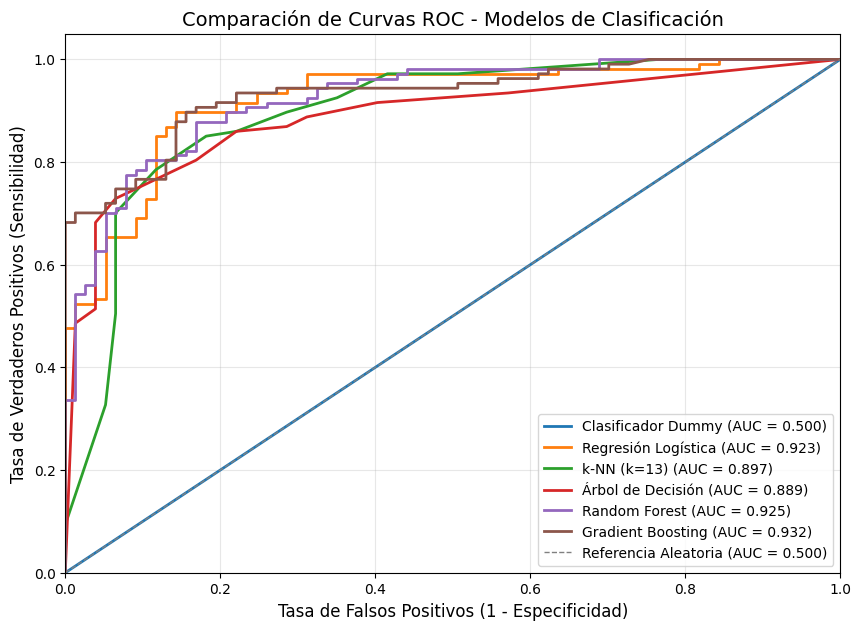

In [165]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def graficar_comparativa_roc(modelos, X_test, y_test):
    """
    Grafica las curvas ROC de múltiples modelos en un solo plot.
    
    Argumentos:
    modelos: Lista de tuplas [('Nombre', pipeline), ...]
    X_test: Datos de prueba
    y_test: Etiquetas reales
    """
    plt.figure(figsize=(10, 7))
    
    for nombre, pipeline in modelos:
        # Obtener probabilidades de la clase positiva
        y_probs = pipeline.predict_proba(X_test)[:, 1]
        
        # Calcular FPR, TPR y AUC
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        
        # Añadir al gráfico
        plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc:.3f})')
    
    # Línea de referencia aleatoria
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Referencia Aleatoria (AUC = 0.500)')
    
    # Configuración estética
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
    plt.title('Comparación de Curvas ROC - Modelos de Clasificación', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # Guardar la imagen
    plt.savefig('comparativa_roc_modelos.png')

# --- Ejemplo de uso ---
# Primero agrupamos tus modelos en una lista de tuplas
modelos_a_comparar = [
    ('Clasificador Dummy', pipeline_dummy),
    ('Regresión Logística', pipeline_logit),
    ('k-NN (k=13)', pipeline_knn),
    ('Árbol de Decisión', pipeline_tree),
    ('Random Forest', pipeline_rf),
    ('Gradient Boosting', pipeline_gb)
]

# Llamamos a la función
graficar_comparativa_roc(modelos_a_comparar, X_test, y_test)

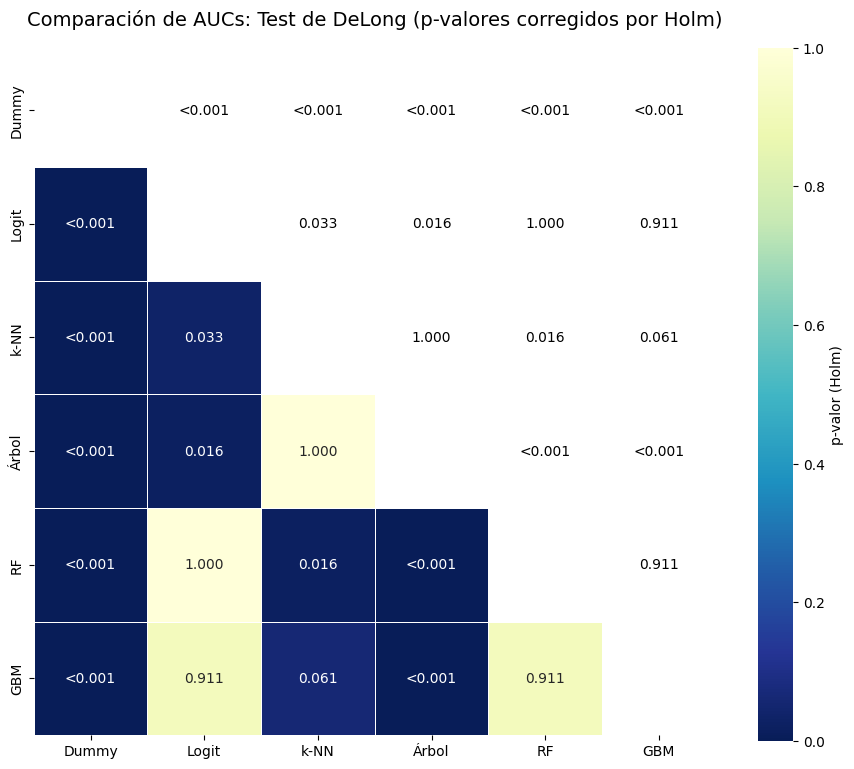


--- Parejas con Diferencias Estadísticamente Significativas ---
       M1     M2         p    p_corr
0   Dummy  Logit  0.000000  0.000000
1   Dummy   k-NN  0.000000  0.000000
2   Dummy  Árbol  0.000000  0.000000
3   Dummy     RF  0.000000  0.000000
4   Dummy    GBM  0.000000  0.000000
13  Árbol    GBM  0.000007  0.000071
12  Árbol     RF  0.000032  0.000289
6   Logit  Árbol  0.002240  0.016041
10   k-NN     RF  0.002005  0.016041
5   Logit   k-NN  0.005522  0.033135


In [167]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

# --- FUNCIONES ESTADÍSTICAS (MÉTODO DE DELONG) ---

def delong_roc_variance(ground_truth, predictions):
    order = np.argsort(predictions)
    ground_truth = ground_truth[order]
    predictions = predictions[order]
    
    n_pos = np.sum(ground_truth)
    n_neg = len(ground_truth) - n_pos
    
    ranks = stats.rankdata(predictions)
    v10 = (ranks[ground_truth == 1] - stats.rankdata(predictions[ground_truth == 1])) / n_neg
    v01 = (n_pos + 1 - (ranks[ground_truth == 0] - stats.rankdata(predictions[ground_truth == 0]))) / n_pos
    
    auc = np.mean(v10)
    var_auc = (np.var(v10) / n_pos) + (np.var(v01) / n_neg)
    return auc, var_auc, v10, v01

def delong_roc_test(ground_truth, probas1, probas2):
    auc1, var1, v10_1, v01_1 = delong_roc_variance(ground_truth, probas1)
    auc2, var2, v10_2, v01_2 = delong_roc_variance(ground_truth, probas2)
    
    cov12 = (np.cov(v10_1, v10_2, ddof=1)[0, 1] / len(v10_1)) + \
            (np.cov(v01_1, v01_2, ddof=1)[0, 1] / len(v01_1))
    
    z = (auc1 - auc2) / np.sqrt(var1 + var2 - 2 * cov12)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z)))
    return p_value

# 1. Lista de modelos
modelos_a_comparar = [
    ('Dummy', pipeline_dummy),
    ('Logit', pipeline_logit),
    ('k-NN', pipeline_knn),
    ('Árbol', pipeline_tree),
    ('RF', pipeline_rf),
    ('GBM', pipeline_gb)
]

# 2. Obtener probabilidades
n_modelos = len(modelos_a_comparar)
nombres = [m[0] for m in modelos_a_comparar]
probas = {nombre: pipe.predict_proba(X_test)[:, 1] for nombre, pipe in modelos_a_comparar}

# 3. Comparaciones por pares
resultados = []
for i in range(n_modelos):
    for j in range(i + 1, n_modelos):
        m1_nom, m2_nom = nombres[i], nombres[j]
        p_val = delong_roc_test(y_test.values, probas[m1_nom], probas[m2_nom])
        resultados.append({'M1': m1_nom, 'M2': m2_nom, 'p': p_val})

# 4. Corrección de Holm
df_comp = pd.DataFrame(resultados)
df_comp['p_corr'] = multipletests(df_comp['p'], method='holm')[1]

# 5. Preparar matrices (P-valores y Anotaciones)
matriz_p = pd.DataFrame(1.0, index=nombres, columns=nombres)
annot_matriz = pd.DataFrame("", index=nombres, columns=nombres)

for _, row in df_comp.iterrows():
    p_final = row['p_corr']
    # Lógica de formato: <0.001 o tres decimales
    texto = "<0.001" if p_final < 0.001 else f"{p_final:.3f}"
    
    # Llenar matriz simétrica
    matriz_p.loc[row['M1'], row['M2']] = p_final
    matriz_p.loc[row['M2'], row['M1']] = p_final
    annot_matriz.loc[row['M1'], row['M2']] = texto
    annot_matriz.loc[row['M2'], row['M1']] = texto

# 6. Visualización Híbrida
plt.figure(figsize=(11, 9))

# Máscara para el triángulo SUPERIOR (donde NO habrá color)
mask_upper = np.triu(np.ones_like(matriz_p, dtype=bool))

# Heatmap solo para el triángulo INFERIOR
ax = sns.heatmap(
    matriz_p, 
    mask=mask_upper, 
    annot=annot_matriz, 
    fmt="", 
    cmap='YlGnBu_r', 
    cbar_kws={'label': 'p-valor (Holm)'},
    square=True,
    linewidths=.5
)

# Añadir manualmente el texto al triángulo SUPERIOR (sin fondo de color)
for i in range(n_modelos):
    for j in range(i + 1, n_modelos):
        valor_texto = annot_matriz.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, valor_texto, 
                ha='center', va='center', color='black', fontsize=10)

plt.title('Comparación de AUCs: Test de DeLong (p-valores corregidos por Holm)', fontsize=14, pad=20)
plt.show()

# Resumen de diferencias significativas
print("\n--- Parejas con Diferencias Estadísticamente Significativas ---")
print(df_comp[df_comp['p_corr'] < 0.05].sort_values('p_corr'))